# Investing in Nashville – Data Analysis and Modeling

This notebook focuses on analyzing Nashville housing data to identify key factors influencing property prices and to build predictive models for identifying high-value investment opportunities.

##### Load Libraries

In [429]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully.')

All libraries loaded successfully.


##### Load Dataset

In [430]:
# Load dataset
df = pd.read_csv("Nashville_housing_data_2013_2016.csv")

##### Initial Data Inspection

In [431]:
# Preview dataset
df.head()

,Unnamed: 0.1,Unnamed: 0,Parcel ID,Land Use,Property Address,Suite/ Condo #,Property City,Sale Date,Sale Price,Legal Reference,Sold As Vacant,Multiple Parcels Involved in Sale,Owner Name,Address,City,State,Acreage,Tax District,Neighborhood,image,Land Value,Building Value,Total Value,Finished Area,Foundation Type,Year Built,Exterior Wall,Grade,Bedrooms,Full Bath,Half Bath
0,0,0,105 03 0D 008.00,RESIDENTIAL CONDO,1208 3RD AVE S,8,NASHVILLE,2013-01-24,132000,20130128-0008725,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,105 11 0 080.00,SINGLE FAMILY,1802 STEWART PL,NaN,NASHVILLE,2013-01-11,191500,20130118-0006337,No,No,"STINSON, LAURA M.",1802 STEWART PL,NASHVILLE,TN,0.17,URBAN SERVICES DISTRICT,3127.0,\114000\910001.JPG,32000.0,134400.0,168300.0,1149.00000,PT BSMT,1941.0,BRICK,C,2.0,1.0,0.0
2,2,2,118 03 0 130.00,SINGLE FAMILY,2761 ROSEDALE PL,NaN,NASHVILLE,2013-01-18,202000,20130124-0008033,No,No,"NUNES, JARED R.",2761 ROSEDALE PL,NASHVILLE,TN,0.11,CITY OF BERRY HILL,9126.0,\131000\191001.JPG,34000.0,157800.0,191800.0,2090.82495,SLAB,2000.0,BRICK/FRAME,C,3.0,2.0,1.0
3,3,3,119 01 0 479.00,SINGLE FAMILY,224 PEACHTREE ST,NaN,NASHVILLE,2013-01-18,32000,20130128-0008863,No,No,"WHITFORD, KAREN",224 PEACHTREE ST,NASHVILLE,TN,0.17,URBAN SERVICES DISTRICT,3130.0,\133000\721001.JPG,25000.0,243700.0,268700.0,2145.60001,FULL BSMT,1948.0,BRICK/FRAME,B,4.0,2.0,0.0
4,4,4,119 05 0 186.00,SINGLE FAMILY,316 LUTIE ST,NaN,NASHVILLE,2013-01-23,102000,20130131-0009929,No,No,"HENDERSON, JAMES P. & LYNN P.",316 LUTIE ST,NASHVILLE,TN,0.34,URBAN SERVICES DISTRICT,3130.0,\134000\474001.JPG,25000.0,138100.0,164800.0,1969.00000,CRAWL,1910.0,FRAME,C,2.0,1.0,0.0


In [432]:
# Dataset shape
df.shape 

(56636, 31)

In [433]:
# Structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56636 entries, 0 to 56635
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0.1                       56636 non-null  int64  
 1   Unnamed: 0                         56636 non-null  int64  
 2   Parcel ID                          56636 non-null  object 
 3   Land Use                           56636 non-null  object 
 4   Property Address                   56477 non-null  object 
 5   Suite/ Condo   #                   6109 non-null   object 
 6   Property City                      56477 non-null  object 
 7   Sale Date                          56636 non-null  object 
 8   Sale Price                         56636 non-null  int64  
 9   Legal Reference                    56636 non-null  object 
 10  Sold As Vacant                     56636 non-null  object 
 11  Multiple Parcels Involved in Sale  56636 non-null  obj

In [434]:
# Summary statistics (Numerical)
df.describe()

,Unnamed: 0.1,Unnamed: 0,Sale Price,Acreage,Neighborhood,Land Value,Building Value,Total Value,Finished Area,Year Built,Bedrooms,Full Bath,Half Bath
count,56636.00000,56636.00000,5.663600e+04,26017.000000,26017.000000,2.601700e+04,2.601700e+04,2.601700e+04,24166.000000,24165.000000,24159.000000,24277.000000,24146.000000
mean,28317.50000,28317.50000,3.272111e+05,0.498903,4356.215782,6.907267e+04,1.608025e+05,2.323971e+05,1926.954345,1963.749224,3.090029,1.886106,0.283981
std,16349.54926,16349.54926,9.287425e+05,1.570396,2170.348270,1.060405e+05,2.068041e+05,2.810703e+05,1687.017313,26.546141,0.852942,0.961572,0.487905
min,0.00000,0.00000,5.000000e+01,0.010000,107.000000,1.000000e+02,0.000000e+00,1.000000e+02,0.000000,1799.000000,0.000000,0.000000,0.000000
25%,14158.75000,14158.75000,1.350000e+05,0.180000,3126.000000,2.100000e+04,7.590000e+04,1.028000e+05,1239.000000,1948.000000,3.000000,1.000000,0.000000
50%,28317.50000,28317.50000,2.054500e+05,0.270000,3929.000000,2.880000e+04,1.114000e+05,1.485000e+05,1632.000000,1960.000000,3.000000,2.000000,0.000000
75%,42476.25000,42476.25000,3.290000e+05,0.450000,6228.000000,6.000000e+04,1.807000e+05,2.685000e+05,2212.000000,1983.000000,3.000000,2.000000,1.000000
max,56635.00000,56635.00000,5.427806e+07,160.060000,9530.000000,2.772000e+06,1.297180e+07,1.394040e+07,197988.000000,2017.000000,11.000000,10.000000,3.000000


In [435]:
# Summary statistics (All Columns)
df.describe(include='all')

,Unnamed: 0.1,Unnamed: 0,Parcel ID,Land Use,Property Address,Suite/ Condo #,Property City,Sale Date,Sale Price,Legal Reference,Sold As Vacant,Multiple Parcels Involved in Sale,Owner Name,Address,City,State,Acreage,Tax District,Neighborhood,image,Land Value,Building Value,Total Value,Finished Area,Foundation Type,Year Built,Exterior Wall,Grade,Bedrooms,Full Bath,Half Bath
count,56636.00000,56636.00000,56636,56636,56477,6109,56477,56636,5.663600e+04,56636,56636,56636,25261,26017,26017,26017,26017.000000,26017,26017.000000,25335,2.601700e+04,2.601700e+04,2.601700e+04,24166.000000,24164,24165.000000,24165,24165,24159.000000,24277.000000,24146.000000
unique,NaN,NaN,48697,39,45068,1952,14,1117,NaN,52898,2,2,19713,22327,12,1,NaN,7,NaN,21831,NaN,NaN,NaN,NaN,6,NaN,10,20,NaN,NaN,NaN
top,NaN,NaN,083 04 0K 001.00,SINGLE FAMILY,1212 LAUREL ST,1,NASHVILLE,2013-06-28,NaN,20150511-0042855,No,No,"JRG PROPERTIES, LLC",0 MCKINLEY ST,NASHVILLE,TN,NaN,URBAN SERVICES DISTRICT,NaN,\36000\736001.JPG,NaN,NaN,NaN,NaN,CRAWL,NaN,BRICK,C,NaN,NaN,NaN
freq,NaN,NaN,4,34268,296,55,40280,305,NaN,116,51741,51947,26,9,20703,26017,NaN,20026,NaN,4,NaN,NaN,NaN,NaN,15389,NaN,11942,17262,NaN,NaN,NaN
mean,28317.50000,28317.50000,NaN,NaN,NaN,NaN,NaN,NaN,3.272111e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.498903,NaN,4356.215782,NaN,6.907267e+04,1.608025e+05,2.323971e+05,1926.954345,NaN,1963.749224,NaN,NaN,3.090029,1.886106,0.283981
std,16349.54926,16349.54926,NaN,NaN,NaN,NaN,NaN,NaN,9.287425e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.570396,NaN,2170.348270,NaN,1.060405e+05,2.068041e+05,2.810703e+05,1687.017313,NaN,26.546141,NaN,NaN,0.852942,0.961572,0.487905
min,0.00000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,107.000000,NaN,1.000000e+02,0.000000e+00,1.000000e+02,0.000000,NaN,1799.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,14158.75000,14158.75000,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.180000,NaN,3126.000000,NaN,2.100000e+04,7.590000e+04,1.028000e+05,1239.000000,NaN,1948.000000,NaN,NaN,3.000000,1.000000,0.000000
50%,28317.50000,28317.50000,NaN,NaN,NaN,NaN,NaN,NaN,2.054500e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.270000,NaN,3929.000000,NaN,2.880000e+04,1.114000e+05,1.485000e+05,1632.000000,NaN,1960.000000,NaN,NaN,3.000000,2.000000,0.000000
75%,42476.25000,42476.25000,NaN,NaN,NaN,NaN,NaN,NaN,3.290000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.450000,NaN,6228.000000,NaN,6.000000e+04,1.807000e+05,2.685000e+05,2212.000000,NaN,1983.000000,NaN,NaN,3.000000,2.000000,1.000000


In [437]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(
    pd.DataFrame(
        {
            "Missing Count": missing, 
            "Missing %": missing_pct
        }
    ).sort_values(by="Missing %", ascending=False)
)

                                   Missing Count  Missing %
Suite/ Condo   #                           50527  89.213574
Half Bath                                  32490  57.366339
Bedrooms                                   32477  57.343386
Foundation Type                            32472  57.334558
Grade                                      32471  57.332792
Exterior Wall                              32471  57.332792
Year Built                                 32471  57.332792
Finished Area                              32470  57.331026
Full Bath                                  32359  57.135038
Owner Name                                 31375  55.397627
image                                      31301  55.266968
Tax District                               30619  54.062787
Total Value                                30619  54.062787
Building Value                             30619  54.062787
Land Value                                 30619  54.062787
Neighborhood                            

In [438]:
# Unique values per column
df.nunique()

Unnamed: 0.1                         56636
Unnamed: 0                           56636
Parcel ID                            48697
Land Use                                39
Property Address                     45068
Suite/ Condo   #                      1952
Property City                           14
Sale Date                             1117
Sale Price                            8085
Legal Reference                      52898
Sold As Vacant                           2
Multiple Parcels Involved in Sale        2
Owner Name                           19713
Address                              22327
City                                    12
State                                    1
Acreage                                519
Tax District                             7
Neighborhood                           203
image                                21831
Land Value                            1122
Building Value                        4406
Total Value                           5848
Finished Ar

In [439]:
# Duplicate rows
print(df.duplicated().sum())

0


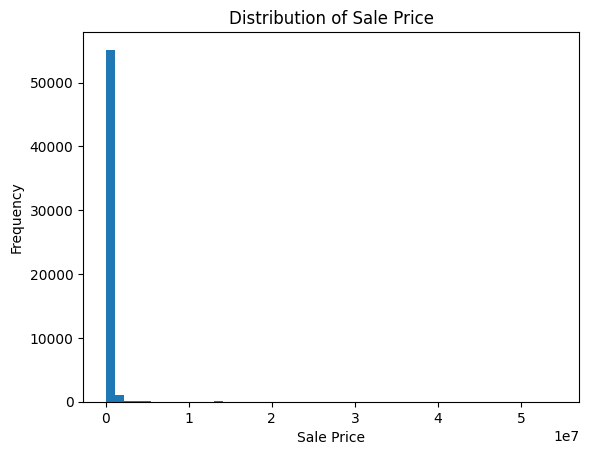

In [440]:
# ===================== PLOT: Sale Price Distribution =====================

plt.figure()
plt.hist(df['Sale Price'], bins=50)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

##### Remove Irrelevant and High-Missing Columns

From the initial data inspection, several columns were identified as unsuitable for modeling due to:

- Extremely high missing values (e.g., over 80%)
- Lack of relevance to property valuation (e.g., owner-related details)
- Being identifiers or artifacts from data collection

Key decisions:
- Remove columns with excessive missingness and low analytical value
- Remove non-property-related features (owner information)
- Retain important property and location-related variables for further processing

This step helps reduce noise and improves model efficiency without losing meaningful information.

In [441]:
# Columns to drop based on analysis
cols_to_drop = [
    'Unnamed: 0.1',
    'Unnamed: 0',
    'Parcel ID',
    'Legal Reference',
    'Suite/ Condo   #',
    'Owner Name',
    'Address',
    'City',
    'State',
    'image'
]

df = df.drop(columns=cols_to_drop)

In [442]:
# Verify remaining structure
print(df.shape)
print()
print(df.columns)

(56636, 21)

Index(['Land Use', 'Property Address', 'Property City', 'Sale Date',
       'Sale Price', 'Sold As Vacant', 'Multiple Parcels Involved in Sale',
       'Acreage', 'Tax District', 'Neighborhood', 'Land Value',
       'Building Value', 'Total Value', 'Finished Area', 'Foundation Type',
       'Year Built', 'Exterior Wall', 'Grade', 'Bedrooms', 'Full Bath',
       'Half Bath'],
      dtype='object')


##### Handle Missing Values (Critical Fields)

The dataset contains a significant amount of missing data across many variables. However, removing all rows with missing values would result in a substantial loss of data.

To preserve as much information as possible:
- We only remove rows where critical location fields are missing (`Property Address`, `Property City`)
- These fields are important for identifying and analyzing properties
- The number of missing values in these columns is very small, so removing them has minimal impact

All other missing values will be handled in later steps using appropriate imputation techniques.

In [443]:
# Drop rows with missing critical location fields
df = df.dropna(subset=['Property Address', 'Property City'])

In [444]:
# Check updated shape
print("Updated shape:", df.shape)

Updated shape: (56477, 21)


In [445]:
# Recalculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values(by="Missing %", ascending=False)

missing_summary

,Missing Count,Missing %
Half Bath,32333,57.249854
Bedrooms,32320,57.226836
Foundation Type,32315,57.217983
Grade,32314,57.216212
Exterior Wall,32314,57.216212
Year Built,32314,57.216212
Finished Area,32313,57.214441
Full Bath,32202,57.017901
Building Value,30462,53.937001
Total Value,30462,53.937001


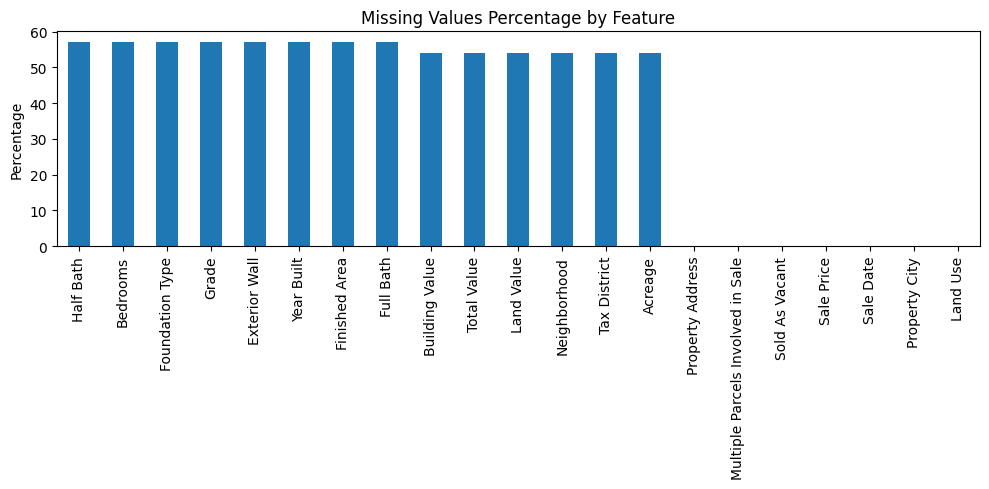

In [446]:
# ===================== PLOT: Missing Values =====================

missing_summary['Missing %'].plot(kind='bar', figsize=(10,5))
plt.title('Missing Values Percentage by Feature')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Impute Missing Numerical Values

Many numerical variables (e.g., Acreage, Land Value, Finished Area) contain over 50% missing values.

Instead of removing these rows, we apply imputation:

- Median is used instead of mean because:
  - The dataset contains extreme outliers (e.g., very high sale prices)
  - Median is more robust and not affected by skewed distributions

This approach preserves the dataset while maintaining realistic values.

In [447]:
# Select numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Exclude target variable
num_cols = num_cols.drop('Sale Price')

# Fill missing numerical values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify no missing numerical values remain
df[num_cols].isnull().sum()

Acreage           0
Neighborhood      0
Land Value        0
Building Value    0
Total Value       0
Finished Area     0
Year Built        0
Bedrooms          0
Full Bath         0
Half Bath         0
dtype: int64

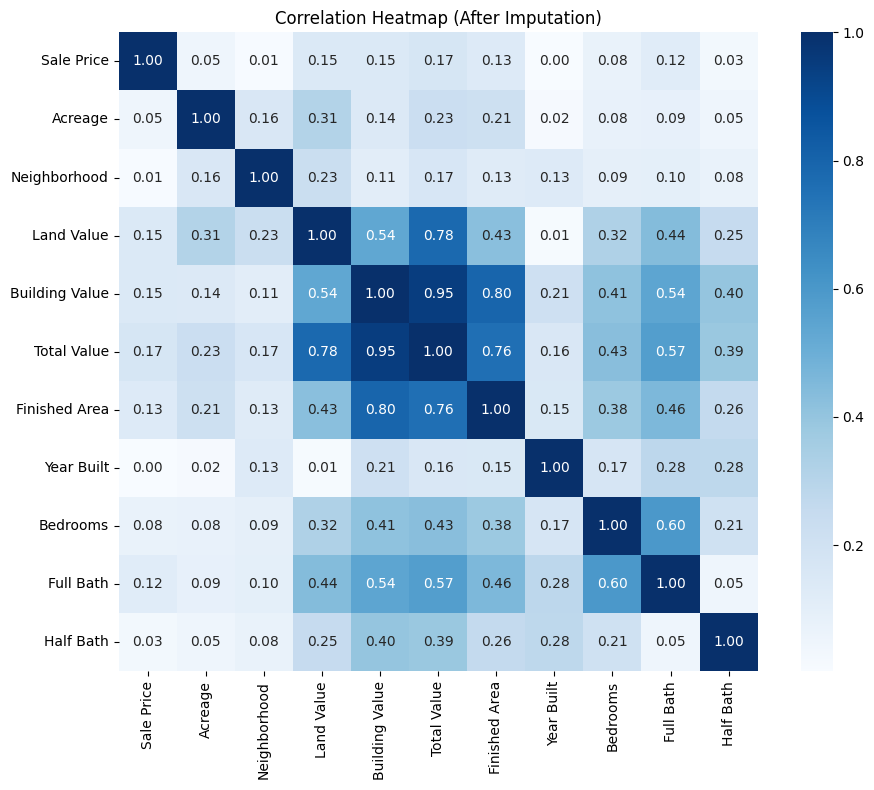

In [448]:
# ===================== PLOT: Correlation Heatmap =====================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='Blues', annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap (After Imputation)')
plt.tight_layout()
plt.show()

##### Impute Missing Categorical Values

Several categorical variables (e.g., Foundation Type, Exterior Wall, Grade, Tax District) contain missing values.

To handle this:

- We use **mode (most frequent value)** for imputation
- This is appropriate because categorical variables represent discrete groups
- Mode preserves the most common real-world category without introducing unrealistic values

This ensures all categorical variables are complete and ready for encoding in later steps.

In [449]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing categorical values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing categorical values remain
df[cat_cols].isnull().sum()

Land Use                             0
Property Address                     0
Property City                        0
Sale Date                            0
Sold As Vacant                       0
Multiple Parcels Involved in Sale    0
Tax District                         0
Foundation Type                      0
Exterior Wall                        0
Grade                                0
dtype: int64

##### Fix Data Types and Create Time-Based Features

The dataset contains variables with incorrect data types, particularly:

- `Sale Date` is stored as a string instead of a datetime object

To improve analysis and modeling:
- Convert `Sale Date` to datetime format
- Extract useful time-based features such as:
  - Sale Year
  - Sale Month

These features help capture market trends and seasonality in housing prices.

In [450]:
# Convert Sale Date to datetime
df['Sale Date'] = pd.to_datetime(df['Sale Date'])

# Extract useful features
df['Sale Year'] = df['Sale Date'].dt.year
df['Sale Month'] = df['Sale Date'].dt.month

# Verify changes
df[['Sale Date', 'Sale Year', 'Sale Month']].head()

,Sale Date,Sale Year,Sale Month
0,2013-01-24,2013,1
1,2013-01-11,2013,1
2,2013-01-18,2013,1
3,2013-01-18,2013,1
4,2013-01-23,2013,1


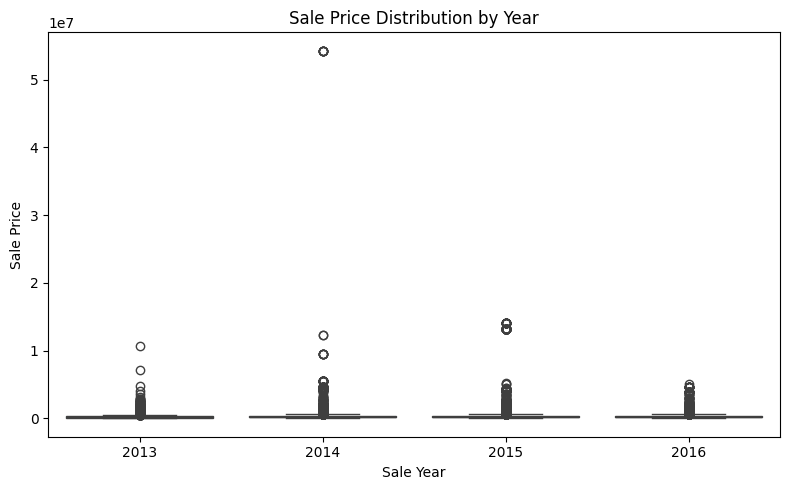

In [451]:
# ===================== PLOT: Sale Price by Year =====================

plt.figure(figsize=(8,5))
sns.boxplot(x='Sale Year', y='Sale Price', data=df)
plt.title('Sale Price Distribution by Year')
plt.tight_layout()
plt.show()

In [452]:
# Drop original date column after feature extraction
df = df.drop(columns=['Sale Date'])

In [453]:
# Verify
print("Final shape:", df.shape)
df.head()

Final shape: (56477, 22)


,Land Use,Property Address,Property City,Sale Price,Sold As Vacant,Multiple Parcels Involved in Sale,Acreage,Tax District,Neighborhood,Land Value,Building Value,Total Value,Finished Area,Foundation Type,Year Built,Exterior Wall,Grade,Bedrooms,Full Bath,Half Bath,Sale Year,Sale Month
0,RESIDENTIAL CONDO,1208 3RD AVE S,NASHVILLE,132000,No,No,0.27,URBAN SERVICES DISTRICT,3929.0,28800.0,111400.0,148500.0,1632.00000,CRAWL,1960.0,BRICK,C,3.0,2.0,0.0,2013,1
1,SINGLE FAMILY,1802 STEWART PL,NASHVILLE,191500,No,No,0.17,URBAN SERVICES DISTRICT,3127.0,32000.0,134400.0,168300.0,1149.00000,PT BSMT,1941.0,BRICK,C,2.0,1.0,0.0,2013,1
2,SINGLE FAMILY,2761 ROSEDALE PL,NASHVILLE,202000,No,No,0.11,CITY OF BERRY HILL,9126.0,34000.0,157800.0,191800.0,2090.82495,SLAB,2000.0,BRICK/FRAME,C,3.0,2.0,1.0,2013,1
3,SINGLE FAMILY,224 PEACHTREE ST,NASHVILLE,32000,No,No,0.17,URBAN SERVICES DISTRICT,3130.0,25000.0,243700.0,268700.0,2145.60001,FULL BSMT,1948.0,BRICK/FRAME,B,4.0,2.0,0.0,2013,1
4,SINGLE FAMILY,316 LUTIE ST,NASHVILLE,102000,No,No,0.34,URBAN SERVICES DISTRICT,3130.0,25000.0,138100.0,164800.0,1969.00000,CRAWL,1910.0,FRAME,C,2.0,1.0,0.0,2013,1


##### Handle Outliers (Capping Instead of Removal)

The dataset contains extreme values in `Sale Price`. However, in real estate data, high prices may represent legitimate luxury properties rather than errors.

Instead of removing these observations, we apply capping (Winsorization):

- Values below the lower bound are set to the lower limit
- Values above the upper bound are set to the upper limit

This approach reduces the impact of extreme values while preserving all observations.

In [454]:
# Calculate IQR bounds
Q1 = df['Sale Price'].quantile(0.25)
Q3 = df['Sale Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Apply capping
df['Sale Price'] = np.where(df['Sale Price'] < lower, lower, df['Sale Price'])
df['Sale Price'] = np.where(df['Sale Price'] > upper, upper, df['Sale Price'])

# Verify
df['Sale Price'].describe()

count     56477.000000
mean     250603.590736
std      159304.333566
min          50.000000
25%      135000.000000
50%      205100.000000
75%      328500.000000
max      618750.000000
Name: Sale Price, dtype: float64

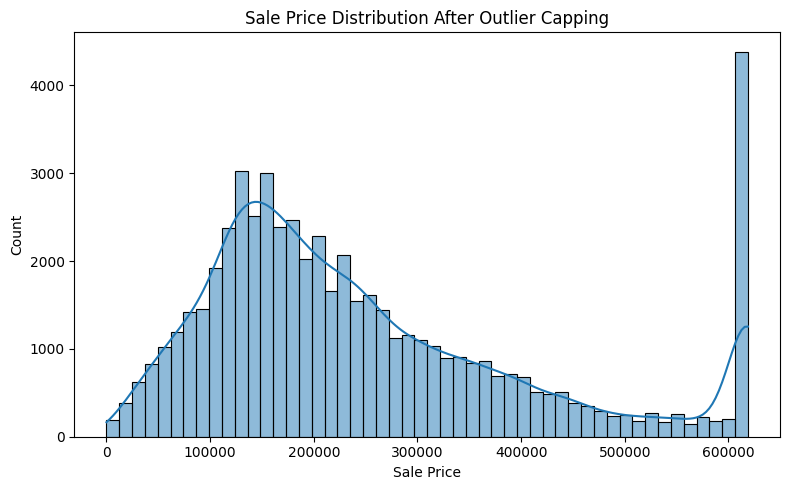

In [455]:
# ===================== PLOT: Sale Price After Outlier Treatment =====================

plt.figure(figsize=(8,5))
sns.histplot(df['Sale Price'], bins=50, kde=True)
plt.title('Sale Price Distribution After Outlier Capping')
plt.tight_layout()
plt.show()

##### Encode Categorical Variables

Categorical variables must be converted into numerical format for machine learning models.

**Handle High-Cardinality Features**
- `Property Address` has extremely high cardinality (~45,000+ unique values)
- It is removed to prevent dimensional explosion and overfitting

**Reduce Noise in `Land Use`**
- A frequency threshold of 500 (~1% of the dataset) is used
- Many categories are very rare
- We group infrequent categories into `"OTHER"` using a frequency threshold

**Simplify `Grade` (Ordinal Feature)**
- `Grade` represents property quality but contains many complex categories
- We simplify it into 4 meaningful groups:
  - Low
  - Average
  - Above Avg
  - High

**Apply One-Hot Encoding**
- Applied to remaining categorical variables
- `drop_first=True` is used to avoid multicollinearity

**Outcome:**
- All features are converted into numerical format
- Dimensionality is controlled
- Noise from rare categories is reduced
- Dataset is ready for machine learning models

In [456]:
df['Property Address'].nunique()

45068

In [457]:
value_counts = df['Land Use'].value_counts()
value_counts

Land Use
SINGLE FAMILY                                 34197
RESIDENTIAL CONDO                             14080
VACANT RESIDENTIAL LAND                        3547
VACANT RES LAND                                1549
DUPLEX                                         1373
ZERO LOT LINE                                  1048
CONDO                                           247
RESIDENTIAL COMBO/MISC                           95
TRIPLEX                                          92
QUADPLEX                                         39
CONDOMINIUM OFC  OR OTHER COM CONDO              35
CHURCH                                           34
MOBILE HOME                                      20
DORMITORY/BOARDING HOUSE                         19
SPLIT CLASS                                      17
VACANT COMMERCIAL LAND                           17
PARKING LOT                                      11
FOREST                                           10
GREENBELT                                        10
PAR

In [458]:
df['Grade'].value_counts()

Grade
C       49576
B        3696
D        1984
A         598
X         523
E          60
TCC        20
IDC         3
AAB         3
AAC         3
OFC         2
SRC         1
SSC         1
SRD         1
TFC         1
TCB         1
TAC         1
OMB         1
OFB         1
TCD         1
Name: count, dtype: int64

In [459]:
# Drop high-cardinality column
df = df.drop(columns=['Property Address'])

# Reduce cardinality: Land Use
threshold = 500
value_counts = df['Land Use'].value_counts()
valid_categories = value_counts[value_counts >= threshold].index

df['Land Use'] = df['Land Use'].apply(
    lambda x: x if x in valid_categories else 'OTHER'
)

# Clean and simplify Grade
df['Grade'] = df['Grade'].str.strip()

def simplify_grade(g):
    if g in ['A', 'AAB', 'AAC', 'TAC', 'TCB', 'TCC', 'TCD', 'TFC', 'SRC']:
        return 'High'
    elif g in ['B', 'SRD', 'SSC']:
        return 'Above_Avg'
    elif g in ['C']:
        return 'Average'
    else:
        return 'Low'

df['Grade'] = df['Grade'].apply(simplify_grade)

# One-Hot Encoding
cat_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [460]:
# Final check
print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (56477, 57)


,Sale Price,Acreage,Neighborhood,Land Value,Building Value,Total Value,Finished Area,Year Built,Bedrooms,Full Bath,Half Bath,Sale Year,Sale Month,Land Use_OTHER,Land Use_RESIDENTIAL CONDO,Land Use_SINGLE FAMILY,Land Use_VACANT RES LAND,Land Use_VACANT RESIDENTIAL LAND,Land Use_ZERO LOT LINE,Property City_BELLEVUE,Property City_BRENTWOOD,Property City_FRANKLIN,Property City_GOODLETTSVILLE,Property City_HERMITAGE,Property City_JOELTON,Property City_MADISON,Property City_MOUNT JULIET,Property City_NASHVILLE,Property City_NOLENSVILLE,Property City_OLD HICKORY,Property City_UNKNOWN,Property City_WHITES CREEK,Sold As Vacant_Yes,Multiple Parcels Involved in Sale_Yes,Tax District_CITY OF BERRY HILL,Tax District_CITY OF FOREST HILLS,Tax District_CITY OF GOODLETTSVILLE,Tax District_CITY OF OAK HILL,Tax District_GENERAL SERVICES DISTRICT,Tax District_URBAN SERVICES DISTRICT,Foundation Type_FULL BSMT,Foundation Type_PIERS,Foundation Type_PT BSMT,Foundation Type_SLAB,Foundation Type_TYPICAL,Exterior Wall_BRICK/FRAME,Exterior Wall_CONC BLK,Exterior Wall_FRAME,Exterior Wall_FRAME/STONE,Exterior Wall_LOG,Exterior Wall_METAL,Exterior Wall_PRECAST CONC,Exterior Wall_STONE,Exterior Wall_STUCCO,Grade_Average,Grade_High,Grade_Low
0,132000.0,0.27,3929.0,28800.0,111400.0,148500.0,1632.00000,1960.0,3.0,2.0,0.0,2013,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,191500.0,0.17,3127.0,32000.0,134400.0,168300.0,1149.00000,1941.0,2.0,1.0,0.0,2013,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,202000.0,0.11,9126.0,34000.0,157800.0,191800.0,2090.82495,2000.0,3.0,2.0,1.0,2013,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0
3,32000.0,0.17,3130.0,25000.0,243700.0,268700.0,2145.60001,1948.0,4.0,2.0,0.0,2013,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,102000.0,0.34,3130.0,25000.0,138100.0,164800.0,1969.00000,1910.0,2.0,1.0,0.0,2013,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


##### Feature Scaling and Train-Test Split

To prepare the dataset for machine learning models, we perform two important steps:

Train-Test Split:

- The dataset is divided into **training (80%)** and **testing (20%)** sets  
- This allows evaluation of model performance on unseen data  
- `random_state=42` ensures reproducibility  

Feature Scaling (Standardization):

- Numerical features are scaled using **StandardScaler**  
- This transforms data to have:  
  - **Mean = 0**  
  - **Standard Deviation = 1**  

- Scaling is important for models sensitive to feature magnitude (e.g., Linear Regression, KNN)

Important:

- The scaler is **fit only on training data** to prevent data leakage  
- The same transformation is applied to the test data  

In [462]:
# Separate features and target
X = df.drop(columns=['Sale Price'])
y = df['Sale Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (45181, 56)
Test shape: (11296, 56)


In [463]:
# Feature Scaling (Standardization)

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [464]:
# Verify
X_train_scaled

array([[-0.24284488, -1.94443434, -0.42821256, ...,  0.37322172,
        -0.10716684, -0.21829125],
       [ 0.55451216,  0.19996923,  1.15212453, ...,  0.37322172,
        -0.10716684, -0.21829125],
       [-0.09388807, -0.13308345, -0.24530927, ...,  0.37322172,
        -0.10716684, -0.21829125],
       ...,
       [-0.09388807, -0.13308345, -0.24530927, ...,  0.37322172,
        -0.10716684, -0.21829125],
       [-0.29541787,  1.41222737, -0.26899459, ...,  0.37322172,
        -0.10716684, -0.21829125],
       [-0.09388807, -0.13308345, -0.24530927, ...,  0.37322172,
        -0.10716684, -0.21829125]], shape=(45181, 56))

##### Train a Baseline Model (Linear Regression)

To establish an initial benchmark, we train a **Linear Regression** model.

Why Linear Regression?:

- Simple and interpretable model  
- Serves as a strong baseline for regression problems  
- Helps assess whether more complex models are necessary  

Evaluation Metrics:

- **MAE (Mean Absolute Error):** Average prediction error  
- **RMSE (Root Mean Squared Error):** Penalizes large errors more heavily  
- **R² Score:** Proportion of variance explained  
- **MAPE:** Percentage-based error for business interpretation  

Outcome:

- Provides a baseline performance metric  
- Future models should aim to improve upon this  

In [465]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Linear Regression Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
print("MAPE (%):", mape)

Linear Regression Metrics:
MAE: 87642.24535048664
RMSE: 119859.52015196947
R² Score: 0.41944310461579404
MAPE (%): 68.30693283705884


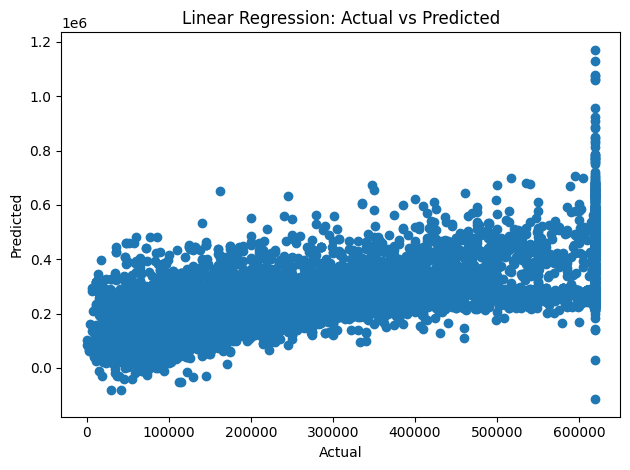

In [466]:
# ===================== PLOT: Actual vs Predicted (Linear Regression) =====================

plt.scatter(y_test, y_pred)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

##### Build a Decision Tree Model

To improve upon the baseline model, we implement a **Decision Tree Regressor**.

Why Decision Tree?

- Captures **non-linear relationships** in the data  
- Handles **feature interactions** automatically  
- Does not require feature scaling  
- Easy to interpret and visualize  

Evaluation Metrics:

- MAE, RMSE, R², MAPE  

Outcome:

- Helps determine if a non-linear model improves performance over Linear Regression  

In [467]:
# Train Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100

print("\nDecision Tree Metrics:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)
print("MAPE (%):", mape_dt)


Decision Tree Metrics:
MAE: 70144.7008585559
RMSE: 106076.3872094057
R² Score: 0.5452872225101932
MAPE (%): 45.7529356492688


##### Build a Random Forest Model

To further improve model performance, we implement a **Random Forest Regressor**.

Why Random Forest?

- Reduces overfitting by combining multiple decision trees (ensemble learning)  
- Improves prediction accuracy and stability  
- Handles non-linear relationships effectively  
- Provides robust feature importance estimates  

Evaluation Metrics:

- MAE, RMSE, R², MAPE  

Outcome:

- Expected to outperform a single Decision Tree  
- Provides a more reliable and generalized model for prediction  

In [468]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("\nRandom Forest Metrics:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)
print("MAPE (%):", mape_rf)


Random Forest Metrics:
MAE: 64419.348793797144
RMSE: 98156.74029104985
R² Score: 0.6106501847313117
MAPE (%): 44.64240780706098


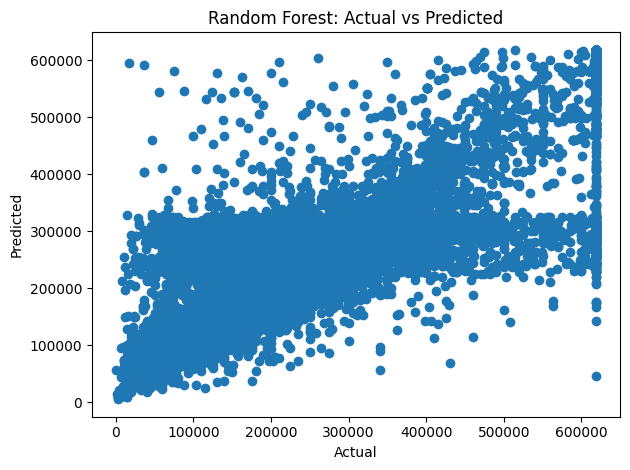

In [469]:
# ===================== PLOT: Actual vs Predicted (Random Forest) =====================

plt.scatter(y_test, y_pred_rf)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

##### Build a Gradient Boosting Model

To further enhance predictive performance, we implement a Gradient Boosting Regressor.

Why Gradient Boosting?

- Builds models sequentially, correcting previous errors
- Often achieves higher accuracy than Random Forest
- Handles complex, non-linear relationships effectively
- Strong performance in structured/tabular data

Evaluation Metrics:

- MAE, RMSE, R², MAPE  

Outcome:

- Typically provides the best performance among tree-based models
- Final candidate for model selection

In [470]:
# Train Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluation
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print("\nGradient Boosting Metrics:")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)
print("MAPE (%):", mape_gb)


Gradient Boosting Metrics:
MAE: 75114.47458764525
RMSE: 107753.00772068457
R² Score: 0.5307994405871903
MAPE (%): 55.62540778904756


##### Model Comparison (All Models)

To determine the best model, we compare performance across multiple metrics.

- Lower MAE, RMSE, and MAPE indicate better performance  
- Higher R² indicates better explanatory power  

This comparison helps identify the most suitable model for real estate investment decisions.

In [471]:
# Create comparison DataFrame
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae, mae_dt, mae_rf, mae_gb],
    'RMSE': [rmse, rmse_dt, rmse_rf, rmse_gb],
    'R2 Score': [r2, r2_dt, r2_rf, r2_gb],
    'MAPE (%)': [mape, mape_dt, mape_rf, mape_gb]
})

model_comparison.sort_values(by='R2 Score', ascending=False)

,Model,MAE,RMSE,R2 Score,MAPE (%)
2,Random Forest,64419.348794,98156.740291,0.610650,44.642408
1,Decision Tree,70144.700859,106076.387209,0.545287,45.752936
3,Gradient Boosting,75114.474588,107753.007721,0.530799,55.625408
0,Linear Regression,87642.245350,119859.520152,0.419443,68.306933


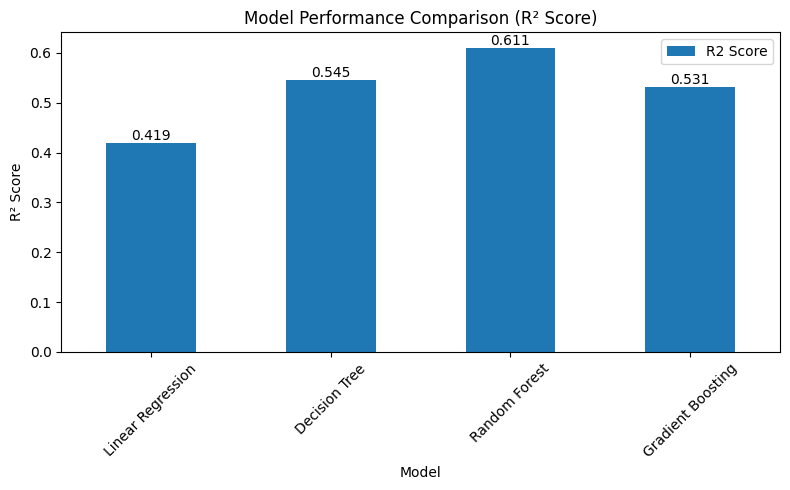

In [482]:
# ===================== PLOT: Model Comparison =====================

ax = model_comparison.set_index('Model')[['R2 Score']].plot(kind='bar', figsize=(8,5))

plt.title('Model Performance Comparison (R² Score)')
plt.ylabel('R² Score')
plt.xticks(rotation=45)

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [473]:
# Feature importance (for business insight)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

Total Value                              0.463506
Land Value                               0.071527
Multiple Parcels Involved in Sale_Yes    0.068166
Sale Month                               0.067670
Sale Year                                0.062538
Sold As Vacant_Yes                       0.041300
Property City_NASHVILLE                  0.037073
Year Built                               0.021638
Land Use_SINGLE FAMILY                   0.018302
Neighborhood                             0.017783
dtype: float64

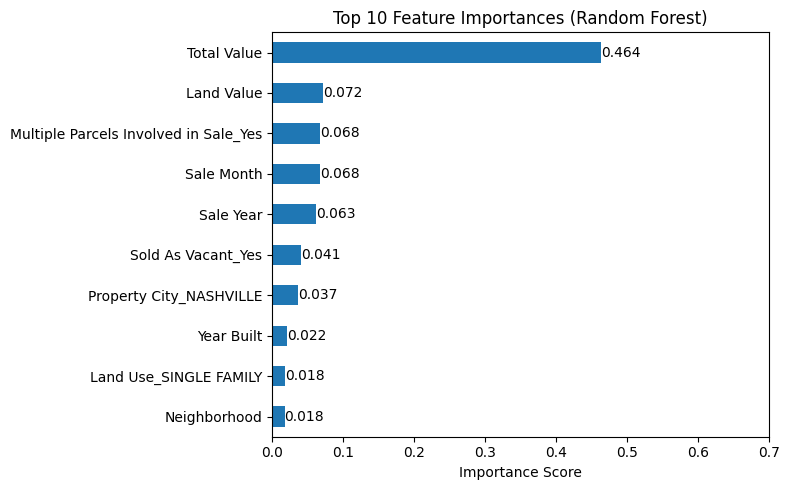

In [481]:
# ===================== PLOT: Feature Importance =====================

top10 = importances.sort_values(ascending=False).head(10)

ax = top10.plot(kind='barh', figsize=(8, 5))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

# Add values beside bars
for i, v in enumerate(top10):
    plt.text(v, i, f'{v:.3f}', va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### Interpretation of Model Performance

The comparison of model performance across multiple evaluation metrics indicates that the Random Forest model consistently outperforms all other models. It achieves the lowest MAE (64,419), lowest RMSE (98,157), and lowest MAPE (44.64%), while also producing the highest R² score (0.611). This indicates that Random Forest provides the most accurate predictions and explains the greatest proportion of variance in housing prices.

The Decision Tree model performs better than Linear Regression, demonstrating its ability to capture non-linear relationships; however, it shows higher error rates and lower explanatory power compared to Random Forest. The Gradient Boosting model performs slightly worse than the Decision Tree in this case, likely due to the use of default hyperparameters without tuning. The Linear Regression model exhibits the weakest performance across all metrics, suggesting that housing prices in this dataset are influenced by complex, non-linear relationships that cannot be effectively captured using a linear approach.

##### Business Insights from Feature Importance

To further support model interpretation, feature importance from the Random Forest model was analyzed. The results show that **Total Value** is the dominant predictor, contributing approximately 46.35% to the model’s predictive power, indicating that assessed property value is the strongest driver of sale price. This is followed by **Land Value** (7.15%), reinforcing the importance of underlying land worth in determining property prices.

Transaction-related variables such as **Multiple Parcels Involved in Sale** (6.82%) and **Sold As Vacant** (4.13%) also play a notable role, suggesting that the structure and condition of the sale can significantly influence pricing outcomes. Temporal factors, including **Sale Month** (6.77%) and **Sale Year** (6.25%), highlight the impact of market timing and seasonal trends on housing prices.

Location remains an important factor, with **Property City (Nashville)** (3.71%) and **Neighborhood** (1.78%) contributing to price variation, confirming that geographic context influences property valuation. Additionally, property characteristics such as **Year Built** (2.16%) and **Land Use (Single Family)** (1.83%) indicate that structural attributes and property type also affect pricing, though to a lesser extent.

Overall, these findings suggest that housing prices in Nashville are primarily driven by property valuation metrics, followed by transaction conditions, market timing, and location factors. This insight enables the real estate company to better identify undervalued properties by focusing on discrepancies between assessed value and actual sale price.

*Note:* Variables such as Total Value and Land Value are closely related to Sale Price and may introduce potential data leakage. While they improve predictive accuracy, caution should be exercised when applying the model in real-world investment decisions.
